In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data_path = "/feynman/work/dap/lcs/vt272285/final_codes/WALE/data/filtertophat_results_15_tomobin5_simulationTrue.npy"

data = np.load(data_path, allow_pickle=True).item()
# Extracting the data

Om_array = []
sig8_array = []
h_array = []
w_array = []
sigma_sq_array = []
l1_array = []
snr_array = []
l1_sim_array = []

# Define common kappa grid
edges = np.linspace(-0.04, 0.04, 801)
centers = 0.5 * (edges[:-1] + edges[1:])

kappas_vals = centers
kappas = []
sim_sigmas = []
for idx, entry in data.items():
    cosmo = entry['cosmology']
    sigma_sq = entry['perturbation_theory_sigma_sq']  # float or scalar
    sim_sigma = entry['simvar']          # float or scalar
    l1s = np.asarray(entry['prediction_l1'])          # shape: (M,)
    snrs = np.asarray(entry['snr'])                   # shape: (M,)
    om = cosmo['Om']
    sig8 = cosmo['sigma8']
    h = cosmo['h']
    w = cosmo['w']
    
    l1_sim = entry['sim_l1_runs']  # shape: (M,n)
    # Ensure shapes: snrs = (800, 1), sqrt_sigma = (1, 10)
    kappa = snrs[:, None] * np.sqrt(sim_sigma)[None, :]

    kappas.append(kappa)
    sigma_sq_array.append(sigma_sq)
    sim_sigmas.append(sim_sigma)
    l1_array.append(l1s)
    l1_sim_array.append(l1_sim)
    snr_array.append(snrs)
    Om_array.append(om)
    sig8_array.append(sig8)
    h_array.append(h)
    w_array.append(w)

Om_array = np.array(Om_array)
sig8_array = np.array(sig8_array)
h_array = np.array(h_array)
w_array = np.array(w_array)
sigma_sq_array = np.array(sigma_sq_array)
l1_array = np.array(l1_array)
l1_sim_array = np.array(l1_sim_array)
snr_array = np.array(snr_array)
kappas = np.array(kappas)
# Transpose last two axes: (n_cosmo, n_bins, n_sim) → (n_cosmo, n_sim, n_bins)
kappas = kappas.transpose(0, 2, 1)

sim_sigmas = np.array(sim_sigmas)


In [4]:
# from scipy.interpolate import InterpolatedUnivariateSpline

# n_cosmo, n_sim, n_bins = l1_sim_array.shape


# # kappa_common = centers #np.linspace(-0.01, 0.01, 600)


# # Container for final l1 values
# l1_final = np.empty((n_cosmo, n_sim, len(kappa_common)))

# for i in range(n_cosmo):
#     for j in range(n_sim):
#         # Original kappa and PDF for this simulation
#         kappa_ij = kappas[i, j, :]          # shape (800,)
#         l1_ij = l1_sim_array[i, j, :]      # shape (800,)
        
#         # Sort if needed (spline requires ascending x)
#         sort_idx = np.argsort(kappa_ij)
#         kappa_sorted = kappa_ij[sort_idx]
#         l1_sorted = l1_ij[sort_idx]
        
#         # Spline interpolation (extrapolate=False → 0 outside range)
#         spline = InterpolatedUnivariateSpline(kappa_sorted, l1_sorted, k=3, ext=1)

#         # Evaluate on common grid
#         l1_interp = spline(kappa_common)
#         l1_interp[l1_interp < 0] = 0  # Avoid small negatives from spline ringing
#         l1_val = l1_interp
#         l1_final[i, j] = l1_val

# # print("Om: ", Om_array)
# # print("sig8: ", sig8_array)
# # print("h: ", h_array)
# # print("w: ", w_array)

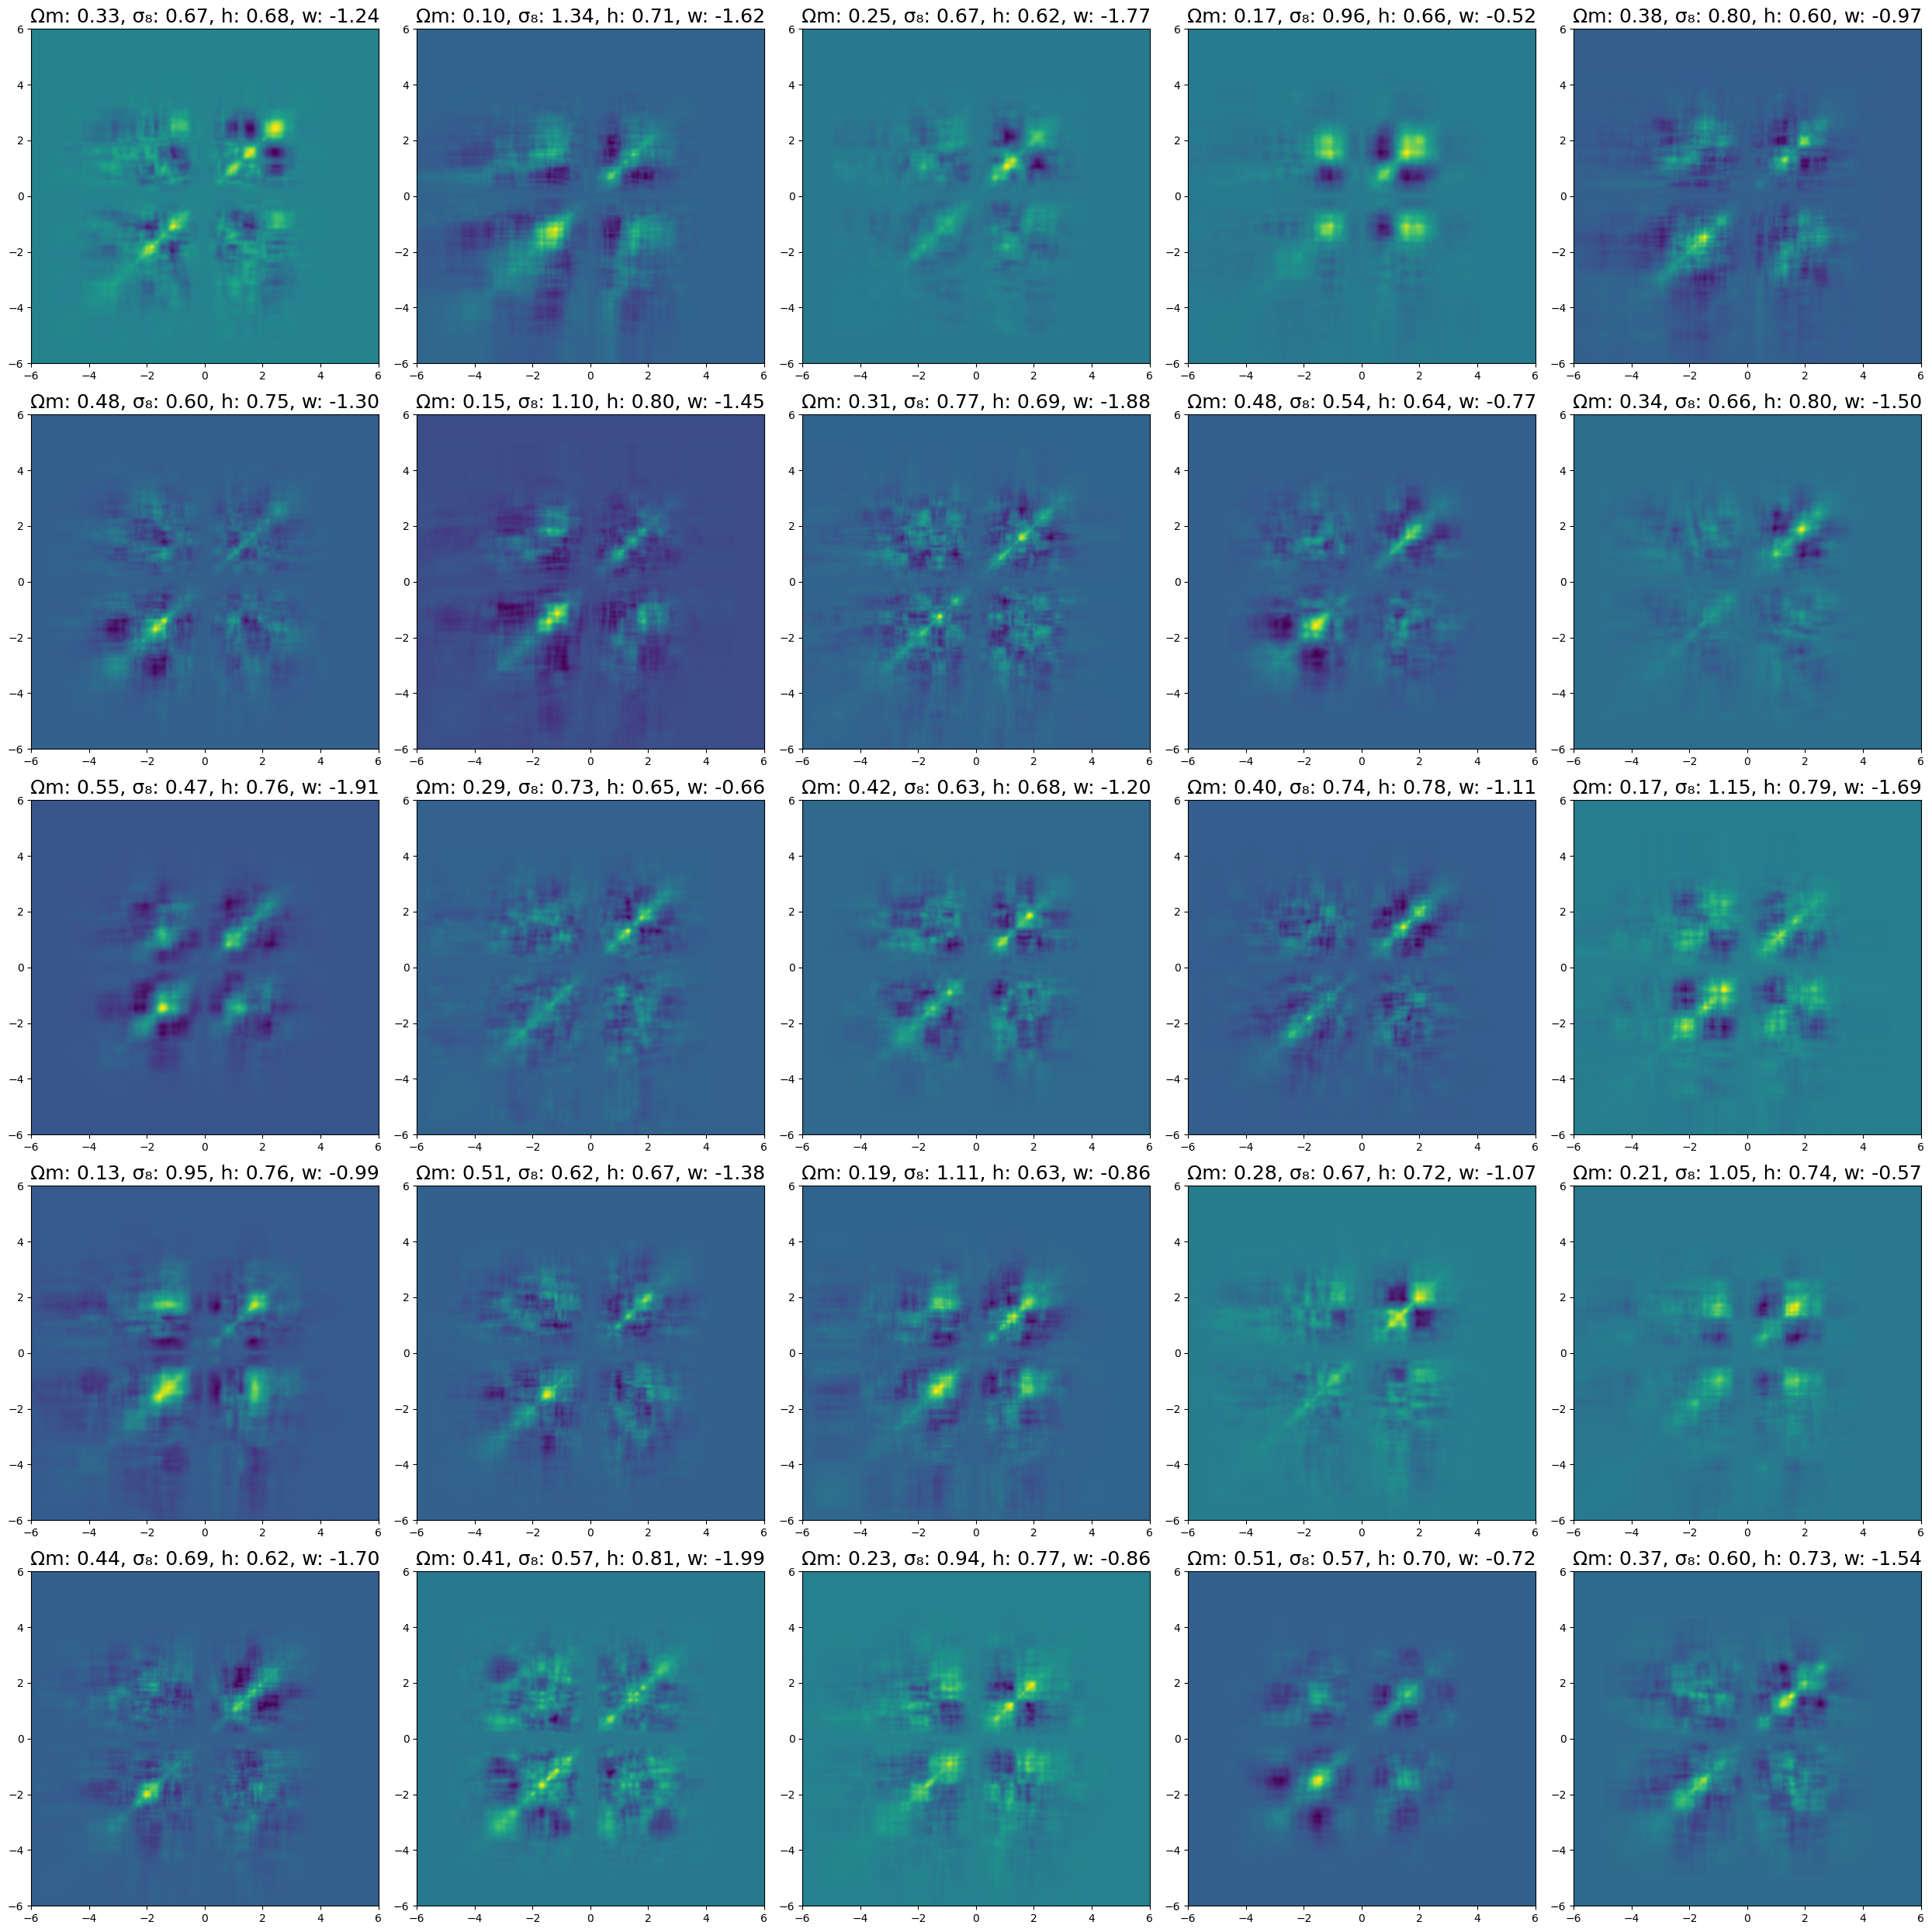

In [5]:
l1_sim_array.shape
n_cosmo, n_sim, n_bins = l1_sim_array.shape

fig, axs = plt.subplots(5, 5, figsize=(25, 25))
covariances = []
for i in range(5):
    for j in range(5):
        ax = axs[i, j]
        idx = i * 5 + j
        if idx < n_cosmo:
            cov = np.cov(l1_sim_array[idx], rowvar=False)  
            covariances.append(cov)
            im = ax.imshow(
                cov, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]]
            )
            ax.set_title(
                f"Ωm: {Om_array[idx]:.2f}, σ₈: {sig8_array[idx]:.2f}, h: {h_array[idx]:.2f}, w: {w_array[idx]:.2f}",
                fontsize=18
            )
        else:
            ax.axis('off')

plt.tight_layout()
plt.show()


/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


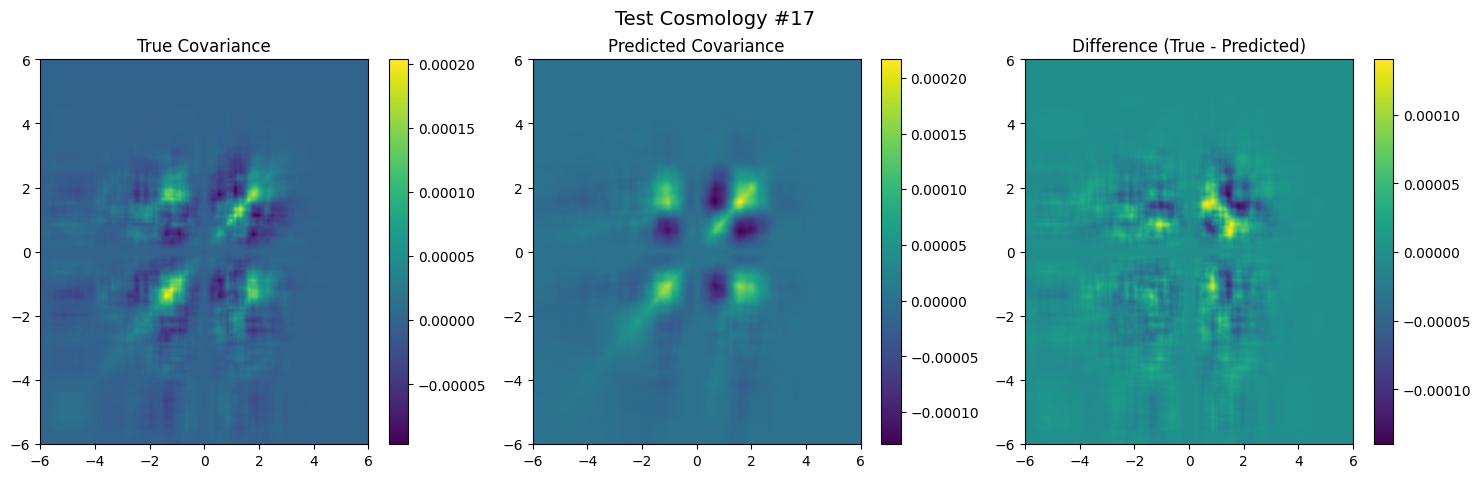

Explained variance ratio: [0.4091122  0.09494545 0.08467741]
Total explained variance: 0.5887


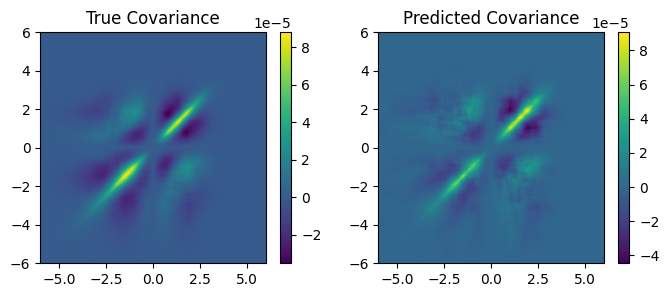

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler

# Stack cosmological params
X_cosmo = np.stack([Om_array, sig8_array, h_array, w_array], axis=1)  # shape: (25, 4)

def vectorize_cov(C):
    return C[np.triu_indices_from(C)]

# Vectorized covariances
cov_vecs = np.array([vectorize_cov(np.cov(l1_sim_array[i], rowvar=False)) for i in range(n_cosmo)])

# Train/test split
X_train, X_test, Y_train, Y_test, idx_train, idx_test = train_test_split(
    X_cosmo, cov_vecs, np.arange(n_cosmo), test_size=1
)

n_components = 3
pca_cov = PCA(n_components=n_components)
Y_train_pca = pca_cov.fit_transform(Y_train)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C


# Fit GP on scaled features
gp_cov_models = []
for i in range(n_components):
    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=1.0, length_scale_bounds=(1e-10, 1e5)), 
        alpha=1e-4, 
        normalize_y=True,
        n_restarts_optimizer=10
    )
    # gp = GaussianProcessRegressor(
    #     kernel=C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0]*4, length_scale_bounds=(1e-3, 1e6)) \
    #      + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e2)), 
    #     alpha=1e-3, 
    #     normalize_y=True,
    #     n_restarts_optimizer=10
    # )
    gp.fit(X_train_scaled, Y_train_pca[:, i])
    gp_cov_models.append(gp)

# Modify predict_covariance accordingly:
def predict_covariance(cosmo_vector):
    cosmo_vector_scaled = scaler_X.transform(cosmo_vector.reshape(1, -1))
    pred_pca = np.array([
        gp.predict(cosmo_vector_scaled)[0] for gp in gp_cov_models
    ])
    pred_cov_vec = pca_cov.inverse_transform(pred_pca)

    n_elements = len(pred_cov_vec)
    n_bins = int((-1 + np.sqrt(1 + 8 * n_elements)) // 2)
    cov_recon = np.zeros((n_bins, n_bins))
    idx = np.triu_indices(n_bins)
    cov_recon[idx] = pred_cov_vec
    cov_recon[(idx[1], idx[0])] = pred_cov_vec
    cov_recon = 0.5 * (cov_recon + cov_recon.T)
    return cov_recon


for i, test_idx in enumerate(idx_test):
    pred_cov = predict_covariance(X_cosmo[test_idx])
    true_cov = np.cov(l1_sim_array[test_idx], rowvar=False)

    plt.figure(figsize=(18, 5))
    plt.suptitle(f"Test Cosmology #{test_idx}", fontsize=14)

    plt.subplot(1, 3, 1)
    plt.imshow(true_cov, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
    plt.title("True Covariance")
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(pred_cov, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
    plt.title("Predicted Covariance")
    plt.colorbar()
    
    plt.subplot(1, 3, 3)
    plt.imshow(true_cov - pred_cov, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
    plt.title("Difference (True - Predicted)")
    plt.colorbar()

    plt.show()

print(f"Explained variance ratio: {pca_cov.explained_variance_ratio_}")
print(f"Total explained variance: {np.sum(pca_cov.explained_variance_ratio_):.4f}")

Om_fid = 0.2905
sig8_fid = 0.8364
h_fid = 0.6898
w_fid = -1.0
cosmo_fid = np.array([Om_fid, sig8_fid, h_fid, w_fid])

# ---------------- Predict with your model ----------------
pred_cov_fid = predict_covariance(cosmo_fid)  # uses your scaler_X, pca_cov, gp_cov_models

# ---------------- Load "true" covariance ----------------
true_cov_fid = np.load("/feynman/work/dap/lcs/vt272285/inference/extrabins/cov_matrix_full_theta15.0_bin5.npy")

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.title("True Covariance")
plt.imshow(true_cov_fid, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
plt.colorbar()
plt.subplot(1,2,2)
plt.title("Predicted Covariance")
plt.imshow(pred_cov_fid, cmap='viridis', aspect='auto', origin='lower',
                extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
plt.colorbar()
# plt.subplot(1,3,3)
# plt.title("Difference (True - Predicted)")
# plt.imshow(true_cov_fid - pred_cov_fid, cmap='viridis', aspect='auto', origin='lower',
#                 extent=[snr_array[0][0], snr_array[0][-1], snr_array[0][0], snr_array[0][-1]])
# plt.colorbar()


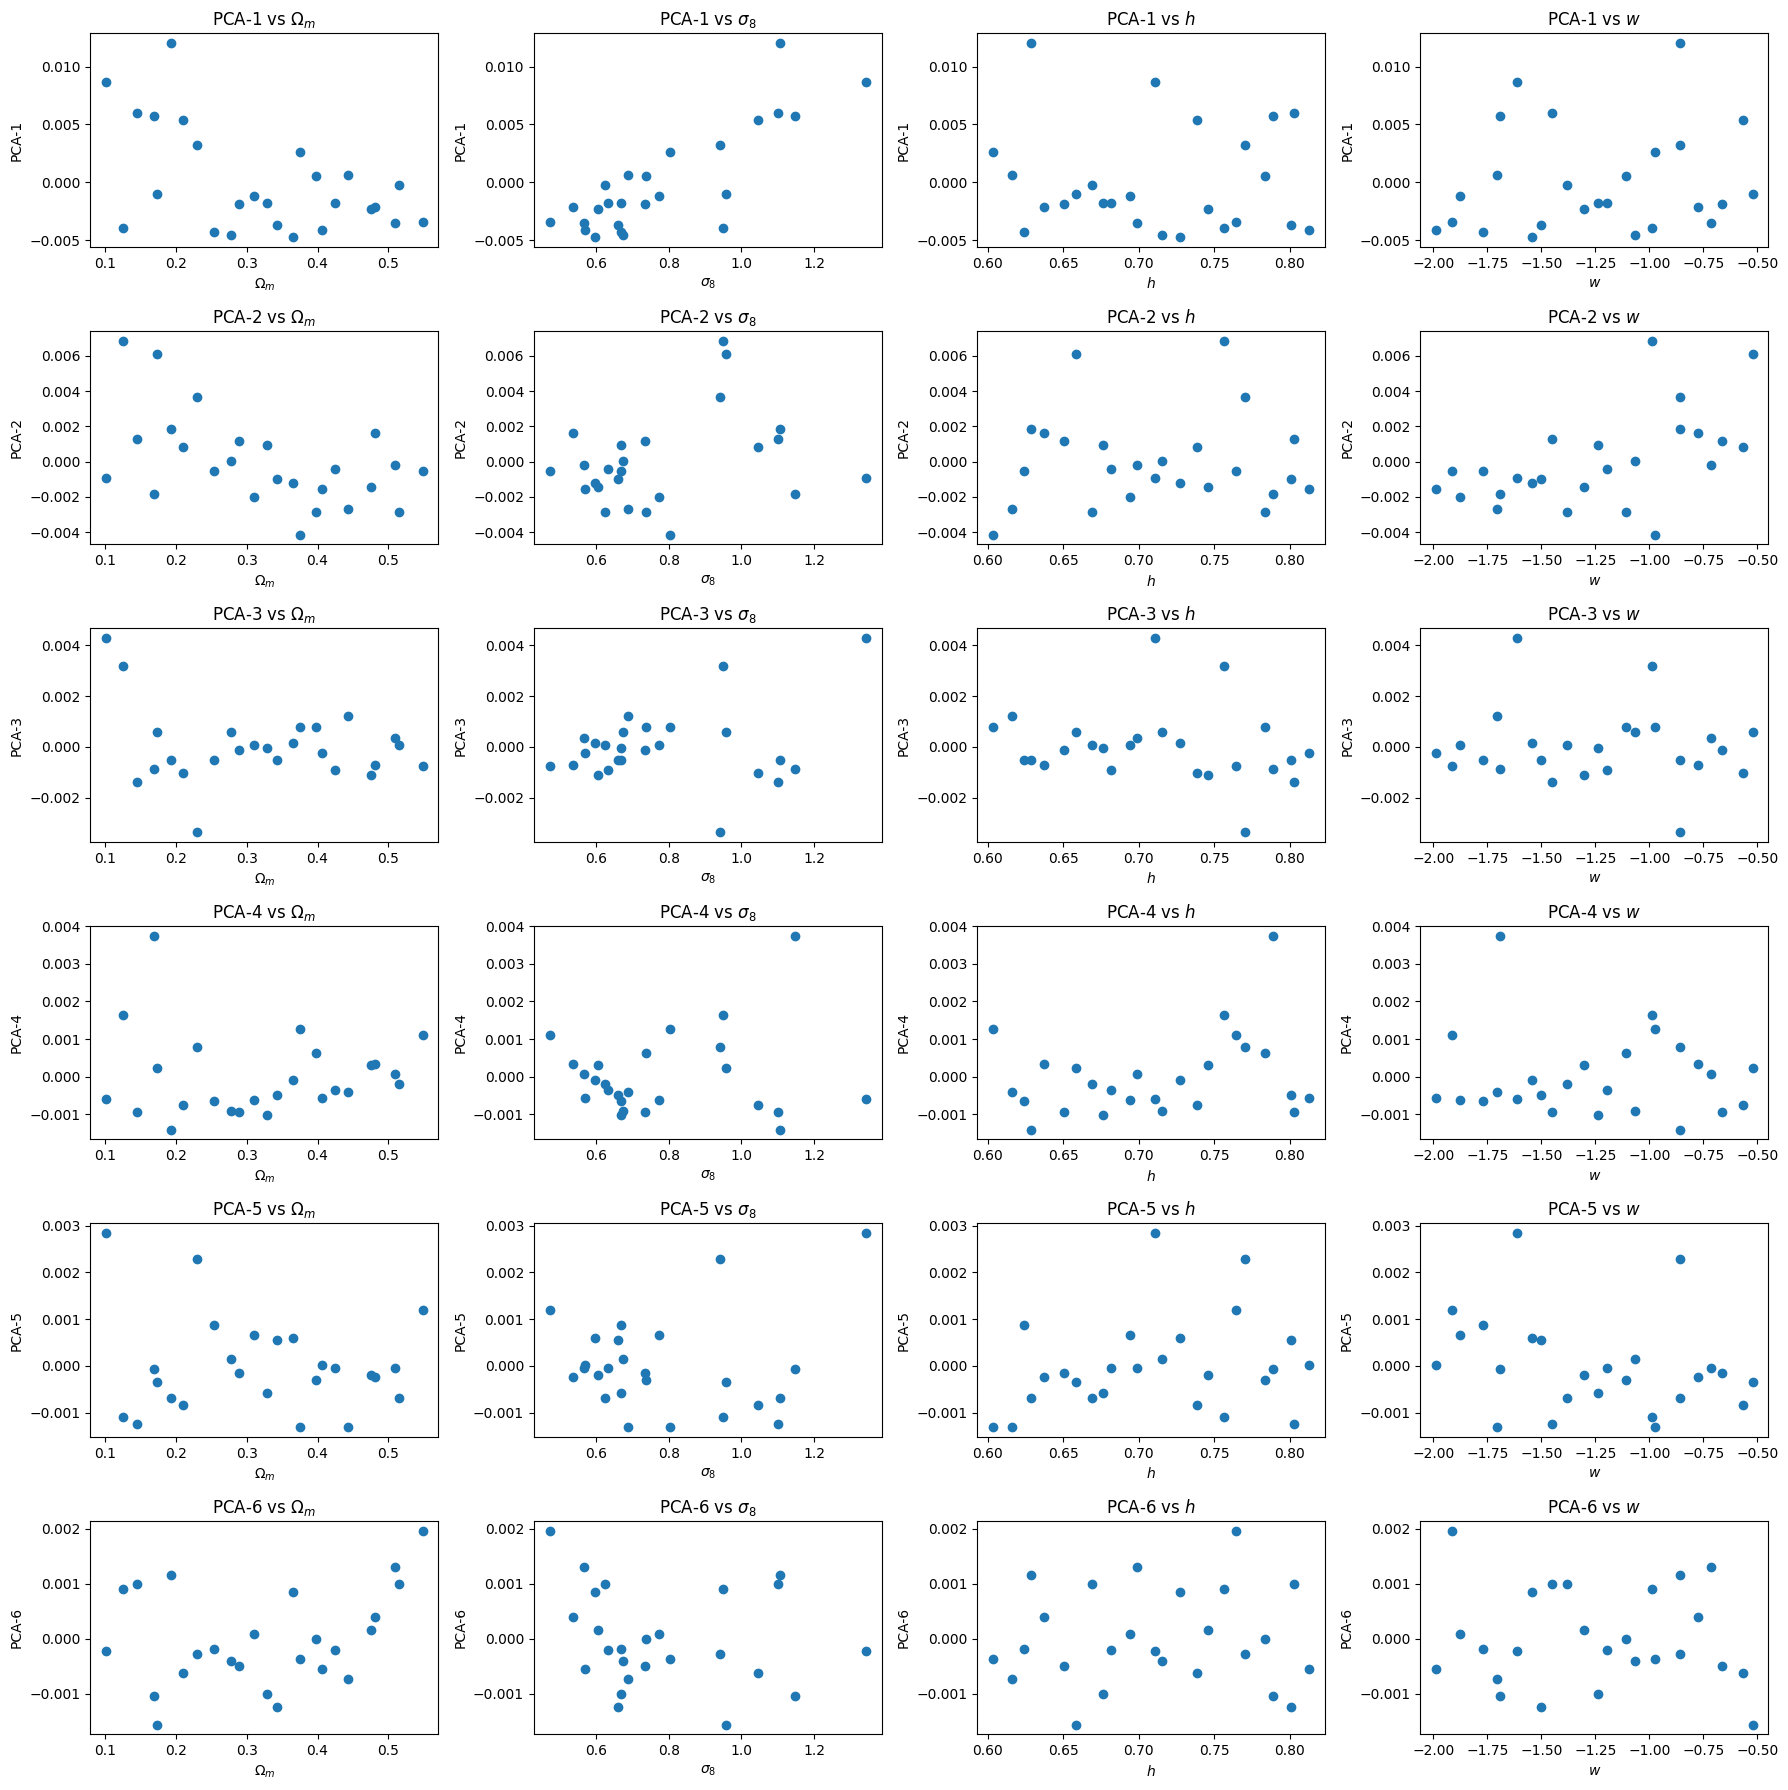

In [82]:
def vectorize_cov(C):
    return C[np.triu_indices_from(C)]

# For each cosmology
cov_vecs = np.array([vectorize_cov(np.cov(l1_final[i], rowvar=False)) for i in range(n_cosmo)])  # (25, 5050)

from sklearn.decomposition import PCA

n_components = 6  # Tune as needed
pca_cov = PCA(n_components=n_components)
cov_pca = pca_cov.fit_transform(cov_vecs)  # (25, 6)

import matplotlib.pyplot as plt

params = [Om_array, sig8_array, h_array, w_array]
param_names = [r'$\Omega_m$', r'$\sigma_8$', r'$h$', r'$w$']

n_components = cov_pca.shape[1]

fig, axs = plt.subplots(n_components, len(params), figsize=(18, 3 * n_components))

for comp in range(n_components):
    for j, (arr, name) in enumerate(zip(params, param_names)):
        axs[comp, j].scatter(arr, cov_pca[:, comp])
        axs[comp, j].set_xlabel(name)
        axs[comp, j].set_ylabel(f'PCA-{comp+1}')
        axs[comp, j].set_title(f'PCA-{comp+1} vs {name}')

plt.tight_layout()
plt.show()




PCA-1(log) ≈ -7.939 + -1.666 log(Ωm) + -1.416 log(σ₈) + 1.342 log(h) + -0.022 w


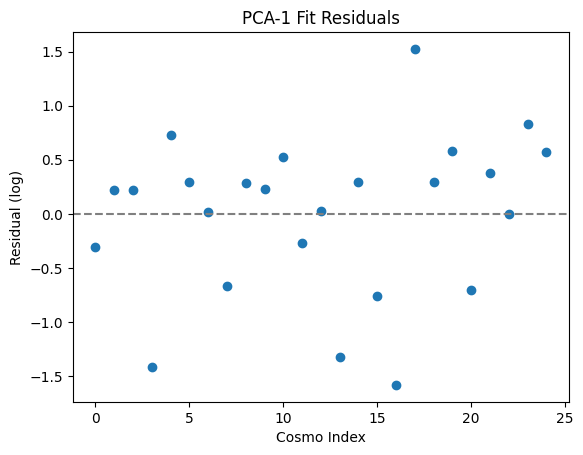

PCA-2(log) ≈ -4.578 + 1.275 log(Ωm) + 3.411 log(σ₈) + -0.615 log(h) + -0.156 w


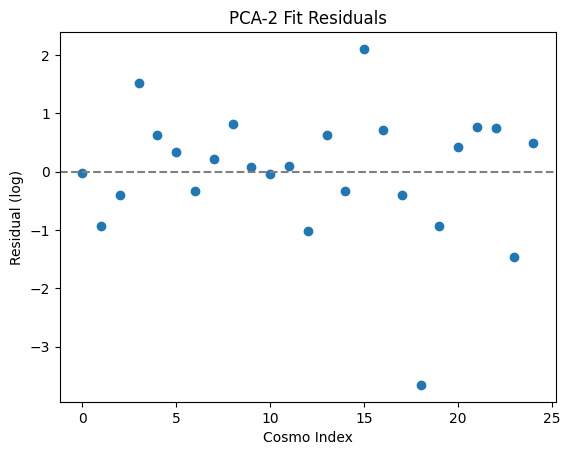

PCA-3(log) ≈ -6.403 + -0.401 log(Ωm) + 1.179 log(σ₈) + 2.638 log(h) + 0.272 w


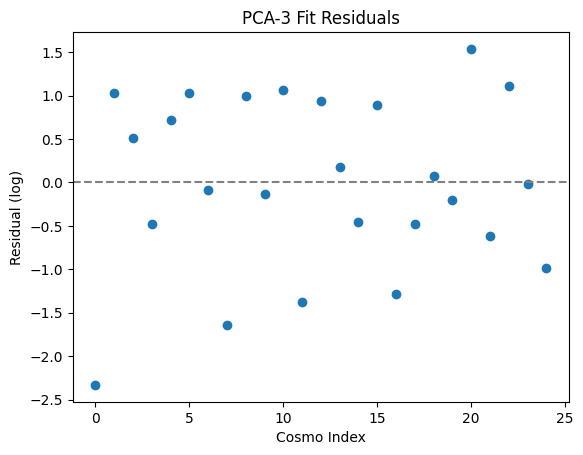

PCA-4(log) ≈ -7.836 + -0.243 log(Ωm) + 1.333 log(σ₈) + 0.344 log(h) + -0.458 w


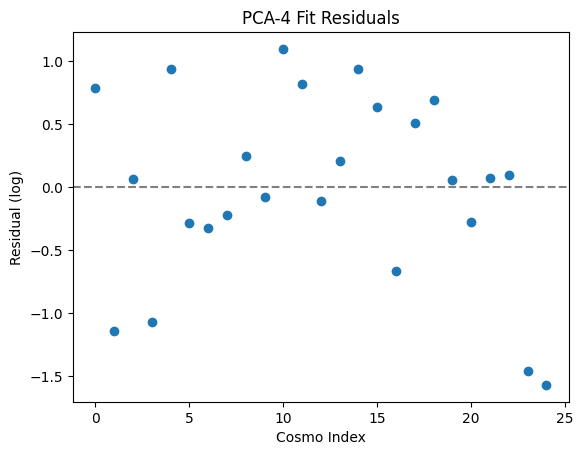

PCA-5(log) ≈ -9.814 + -0.333 log(Ωm) + 1.544 log(σ₈) + -3.852 log(h) + -0.583 w


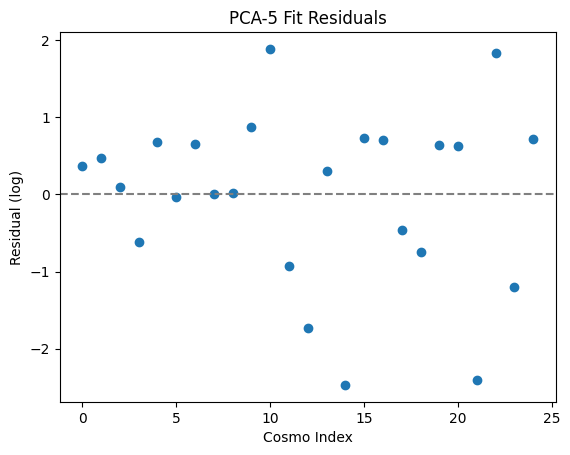

PCA-6(log) ≈ -13.379 + -2.644 log(Ωm) + -4.004 log(σ₈) + -3.551 log(h) + 0.004 w


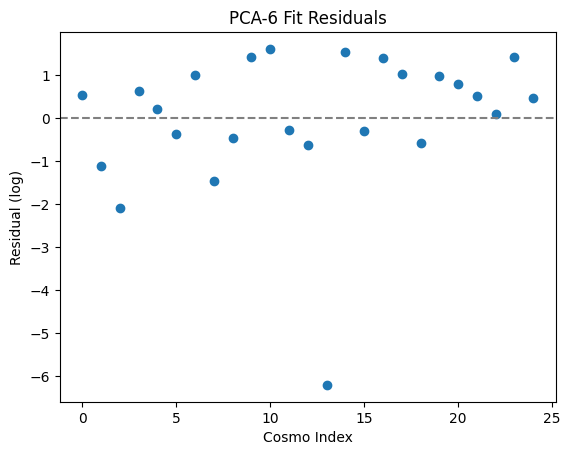

In [83]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Log-linear model
def log_linear_model(x, a, alpha, beta, gamma, delta):
    log_Om, log_sig8, log_h, w = x
    return a + alpha * log_Om + beta * log_sig8 + gamma * log_h + delta * w

# Stack parameters
log_Om = np.log(Om_array)
log_sig8 = np.log(sig8_array)
log_h = np.log(h_array)
w_vals = w_array

X = np.vstack([log_Om, log_sig8, log_h, w_vals])  # shape (4, 25)

# Loop over PCA components
coeffs = []
for i in range(n_components):
    y = cov_pca[:, i]
    y = np.where(y == 0, 1e-10, y)  # Avoid log(0)
    y_log = np.log(np.abs(y))

    popt, _ = curve_fit(log_linear_model, X, y_log)
    coeffs.append(popt)

    # Print formula
    a, alpha, beta, gamma, delta = popt
    print(f"PCA-{i+1}(log) ≈ {a:.3f} + {alpha:.3f} log(Ωm) + {beta:.3f} log(σ₈) + {gamma:.3f} log(h) + {delta:.3f} w")

    # Optional: residual plot
    plt.figure()
    plt.title(f"PCA-{i+1} Fit Residuals")
    plt.scatter(range(len(y_log)), y_log - log_linear_model(X, *popt))
    plt.axhline(0, color='gray', linestyle='--')
    plt.xlabel("Cosmo Index")
    plt.ylabel("Residual (log)")
    plt.show()



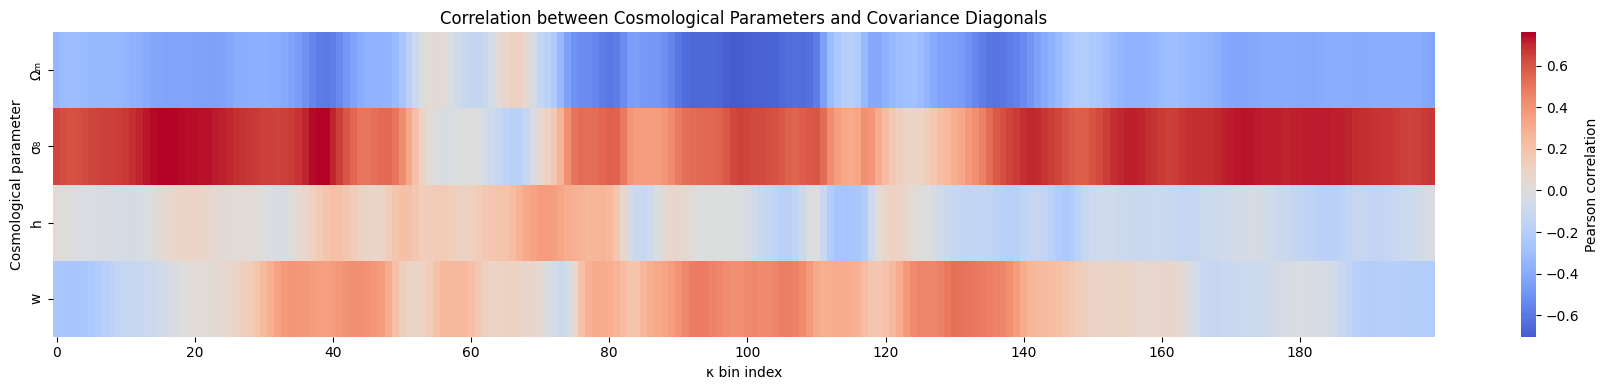

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Assume: diagonals shape = (n_cosmo, n_bins)
# Assume: X_cosmo shape = (n_cosmo, 4)
param_names = ["Ωₘ", "σ₈", "h", "w"]

# Compute Pearson correlation for each (param, bin)
corr_matrix = np.zeros((len(param_names), diagonals.shape[1]))  # shape: (4, n_bins)

for i, param in enumerate([Om_array, sig8_array, h_array, w_array]):
    for j in range(diagonals.shape[1]):
        corr, _ = pearsonr(param, diagonals[:, j])
        corr_matrix[i, j] = corr

plt.figure(figsize=(18, 4))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0,
            xticklabels=20, yticklabels=param_names,
            cbar_kws={"label": "Pearson correlation"})

plt.xlabel("κ bin index")
plt.ylabel("Cosmological parameter")
plt.title("Correlation between Cosmological Parameters and Covariance Diagonals")
plt.tight_layout()
plt.show()


NameError: name 'n_cosmo' is not defined

/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warning

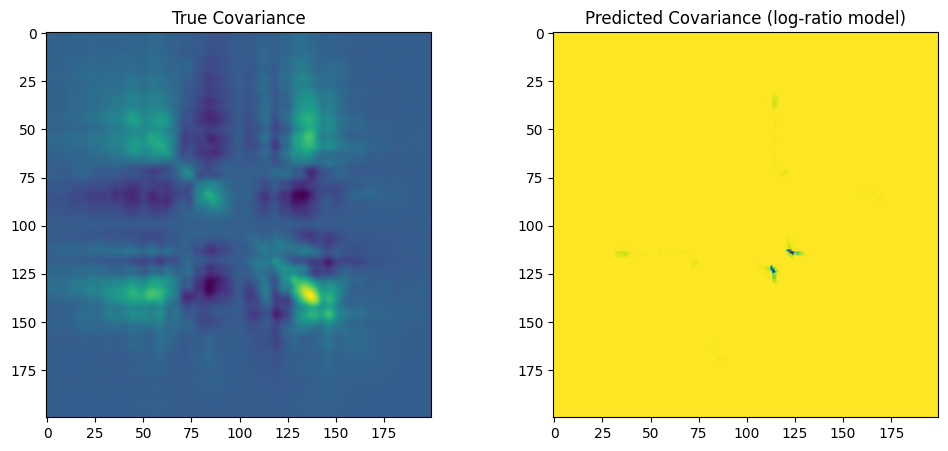

In [70]:
fiducial_idx = 0  # or choose a cosmology index you want as reference
C_fid = np.cov(l1_final[fiducial_idx], rowvar=False)  # shape: (n_bins, n_bins)

# Vectorize fiducial covariance
def vectorize_cov(C):
    """Return the upper triangle (including diagonal) of a symmetric matrix as a 1D array."""
    return C[np.triu_indices_from(C)]

fid_vec = vectorize_cov(C_fid)

log_ratios = []
bad_indices = []

for i in range(n_cosmo):
    vec = vectorize_cov(np.cov(l1_final[i], rowvar=False))
    # add jitter and clip both numerator and denominator
    safe_vec = np.clip(vec, 1e-10, None)
    safe_fid = np.clip(fid_vec, 1e-10, None)
    log_ratio = np.log(safe_vec / safe_fid)
    
    if np.isnan(log_ratio).any():
        print(f"Cosmo {i} has NaN in log_ratio")
        bad_indices.append(i)
    else:
        log_ratios.append(log_ratio)

log_ratios = np.array(log_ratios)



from sklearn.decomposition import PCA

n_components = 6  # tune this
pca_log = PCA(n_components=n_components)
assert not np.isnan(log_ratios).any(), "NaNs still present in log_ratios!"

log_ratios_pca = pca_log.fit_transform(log_ratios)

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

X_cosmo = np.stack([Om_array, sig8_array, h_array, w_array], axis=1)
gp_models = []

for i in range(n_components):
    gp = GaussianProcessRegressor(kernel=RBF(length_scale=1.0), alpha=1e-8, normalize_y=True)
    gp.fit(X_cosmo, log_ratios_pca[:, i])
    gp_models.append(gp)

def reconstruct_cov(vec):
    """Reconstruct a symmetric matrix from its upper-triangular vectorized form."""
    n_bins = int((-1 + np.sqrt(1 + 8 * len(vec))) // 2)
    cov = np.zeros((n_bins, n_bins))
    idx = np.triu_indices(n_bins)
    cov[idx] = vec
    cov[(idx[1], idx[0])] = vec  # mirror to lower triangle
    return 0.5 * (cov + cov.T)


def predict_cov_wrt_fiducial(cosmo_vector):
    # Predict PCA components
    pred_pca = np.array([gp.predict(cosmo_vector.reshape(1, -1))[0] for gp in gp_models])
    
    # Inverse transform log-ratio vector
    pred_log_ratio_vec = pca_log.inverse_transform(pred_pca)

    # Multiply back: Σ = exp(log-ratio) * Σ_fid
    pred_cov_vec = np.exp(pred_log_ratio_vec) * fid_vec

    # Reconstruct full symmetric matrix
    n_bins = int((-1 + np.sqrt(1 + 8 * len(pred_cov_vec))) // 2)
    cov_recon = np.zeros((n_bins, n_bins))
    idx = np.triu_indices(n_bins)
    # cov_recon[idx] = pred_cov_vec
    # cov_recon[(idx[1], idx[0])] = pred_cov_vec
    # cov_recon = 0.5 * (cov_recon + cov_recon.T)
    cov_recon = reconstruct_cov(pred_cov_vec)

    return cov_recon

test_idx = 2
pred_cov = predict_cov_wrt_fiducial(X_cosmo[test_idx])
true_cov = np.cov(l1_final[test_idx], rowvar=False)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(true_cov, cmap='viridis')
plt.title("True Covariance")

plt.subplot(1, 2, 2)
plt.imshow(pred_cov, cmap='viridis')
plt.title("Predicted Covariance (log-ratio model)")
plt.show()



